# 🏭 Notebook 03 — Convolutional Autoencoder Training
## Unsupervised Industrial Defect Detection | MVTec AD Benchmark

**Method:** Reconstruction-Based Anomaly Detection (Conv-AE)  
**Training:** Normal images ONLY — unsupervised one-class learning  
**Categories:** leather · tile · metal_nut  
**Prerequisite:** Notebook 00 + 01 completed. `config.json` and `val_indices.json` must exist on Drive.

---

### PRE-STEP — Install Missing Packages

In [1]:
# ─────────────────────────────────────────────────────────────────
# PRE-STEP — Install packages absent from Colab default environment
# Safe to re-run — skips if already installed
# ─────────────────────────────────────────────────────────────────

import importlib, subprocess, sys

def install_if_missing(module_name: str, pip_name: str):
    if importlib.util.find_spec(module_name) is None:
        print(f'📦 Installing {pip_name}...')
        result = subprocess.run(
            [sys.executable, '-m', 'pip', 'install', '--quiet', pip_name],
            capture_output=True, text=True
        )
        if result.returncode != 0:
            raise RuntimeError(f'❌ Failed to install {pip_name}:\n{result.stderr}')
        print(f'  ✅ {pip_name} installed.')
    else:
        print(f'  ⏭️  {pip_name} already available.')

install_if_missing('pytorch_msssim', 'pytorch-msssim')
install_if_missing('psutil',         'psutil')
print('\n✅ Dependencies ready.')

📦 Installing pytorch-msssim...
  ✅ pytorch-msssim installed.
  ⏭️  psutil already available.

✅ Dependencies ready.


---
### STEP 0 — Imports

In [2]:
# ─────────────────────────────────────────────────────────────────
# STEP 0 — Imports
# ─────────────────────────────────────────────────────────────────

import os, json, gc, random, time, warnings
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.cuda.amp import autocast, GradScaler
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import psutil
from pytorch_msssim import SSIM

warnings.filterwarnings('ignore')
print('✅ Imports complete.')

✅ Imports complete.


---
### STEP 1 — Load Config + Set Device

In [3]:
# ─────────────────────────────────────────────────────────────────
# STEP 1 — Load config + device setup
# ─────────────────────────────────────────────────────────────────

from google.colab import drive
drive.mount('/content/drive', force_remount=False)

PROJECT_NAME = 'industrial_anomaly_project'
DRIVE_ROOT   = f'/content/drive/MyDrive/{PROJECT_NAME}'
CONFIG_PATH  = f'{DRIVE_ROOT}/configs/config.json'

if not os.path.exists(CONFIG_PATH):
    raise FileNotFoundError(
        f'❌ config.json not found. Run Notebook 00 first.\n{CONFIG_PATH}'
    )

with open(CONFIG_PATH) as f:
    cfg = json.load(f)

# ── Unpack paths & hyperparams ────────────────────────────────────
DATASET_DRIVE  = cfg['DATASET_DRIVE']
MODEL_DRIVE    = cfg['MODEL_DRIVE']
RESULTS_DRIVE  = cfg['RESULTS_DRIVE']
LOGS_DRIVE     = cfg['LOGS_DRIVE']
CONFIG_DRIVE   = cfg['CONFIG_DRIVE']
LOCAL_ROOT     = cfg['LOCAL_ROOT']
LOCAL_DATA     = cfg['LOCAL_DATA']
LOCAL_TEMP     = cfg['LOCAL_TEMP']
LOCAL_MODELS   = cfg['LOCAL_MODELS']
CATEGORIES     = cfg['CATEGORIES']
SEED           = cfg['SEED']
IMAGE_SIZE     = cfg['IMAGE_SIZE']
IMAGENET_MEAN  = cfg['IMAGENET_MEAN']
IMAGENET_STD   = cfg['IMAGENET_STD']
VAL_SPLIT      = cfg['VAL_SPLIT']

# AE hyperparams
AE_EPOCHS      = cfg['AE_EPOCHS']       # 50
AE_BATCH_SIZE  = cfg['AE_BATCH_SIZE']   # 16
AE_LR          = cfg['AE_LR']           # 1e-3
AE_WD          = cfg['AE_WEIGHT_DECAY'] # 1e-5
AE_ALPHA       = cfg['AE_LOSS_ALPHA']   # 0.8

# ── Recreate local dirs ───────────────────────────────────────────
for d in [LOCAL_ROOT, LOCAL_DATA, LOCAL_TEMP, LOCAL_MODELS]:
    os.makedirs(d, exist_ok=True)
for d in [MODEL_DRIVE, RESULTS_DRIVE, LOGS_DRIVE]:
    os.makedirs(d, exist_ok=True)

# ── Reproducibility ───────────────────────────────────────────────
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

# ── Device ────────────────────────────────────────────────────────
if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
    gpu_name  = torch.cuda.get_device_name(0)
    gpu_total = torch.cuda.get_device_properties(0).total_memory / (1024**3)
    print(f'✅ GPU : {gpu_name} | VRAM: {gpu_total:.2f} GB')
else:
    DEVICE = torch.device('cpu')
    print('⚠️  No GPU — AE training will be very slow.')

print(f'   Device     : {DEVICE}')
print(f'   Seed       : {SEED}')
print(f'   Epochs     : {AE_EPOCHS}')
print(f'   Batch size : {AE_BATCH_SIZE}')
print(f'   LR         : {AE_LR}')
print(f'   Loss alpha : {AE_ALPHA} * MSE + {1-AE_ALPHA} * (1-SSIM)')

# ── Memory utils ─────────────────────────────────────────────────
def clear_memory():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

def print_mem():
    vm = psutil.virtual_memory()
    ram = f'{vm.used/1e9:.1f}/{vm.total/1e9:.1f} GB ({vm.percent:.0f}%)'
    if torch.cuda.is_available():
        vu = torch.cuda.memory_allocated(0)/1e9
        vt = torch.cuda.get_device_properties(0).total_memory/1e9
        print(f'   RAM: {ram} | VRAM: {vu:.2f}/{vt:.2f} GB')
    else:
        print(f'   RAM: {ram}')

Mounted at /content/drive
✅ GPU : Tesla T4 | VRAM: 14.56 GB
   Device     : cuda
   Seed       : 42
   Epochs     : 50
   Batch size : 16
   LR         : 0.001
   Loss alpha : 0.8 * MSE + 0.19999999999999996 * (1-SSIM)


---
### STEP 1b — Restore Local Dataset from Drive

In [4]:
# ─────────────────────────────────────────────────────────────────
# STEP 1b — Restore dataset to /content/ SSD (run after session reset)
# /content/ is ephemeral — lost on every Colab disconnect.
# ─────────────────────────────────────────────────────────────────

import shutil

print('🔍 Checking local dataset availability...\n')

for cat in CATEGORIES:
    src  = os.path.join(DATASET_DRIVE, cat)
    dest = os.path.join(LOCAL_DATA, cat)
    dest_ok = (
        os.path.exists(dest) and
        os.path.exists(os.path.join(dest, 'train', 'good')) and
        len(os.listdir(os.path.join(dest, 'train', 'good'))) > 0
    )
    if dest_ok:
        n = len(os.listdir(os.path.join(dest, 'train', 'good')))
        print(f'  ⏭️  {cat:<12}: already at LOCAL_DATA ({n} train images) — skipped.')
        continue
    if not os.path.exists(src):
        raise FileNotFoundError(f'❌ Not on Drive: {src}. Re-run Notebook 01.')
    t0 = time.time()
    print(f'  📋 {cat:<12}: copying from Drive...', end='', flush=True)
    if os.path.exists(dest):
        shutil.rmtree(dest)
    shutil.copytree(src, dest)
    n = len(os.listdir(os.path.join(dest, 'train', 'good')))
    print(f' done in {time.time()-t0:.1f}s ({n} train images)')

print('\n✅ All categories available at LOCAL_DATA.')

🔍 Checking local dataset availability...

  📋 leather     : copying from Drive... done in 236.9s (245 train images)
  📋 tile        : copying from Drive... done in 181.9s (230 train images)
  📋 metal_nut   : copying from Drive... done in 191.3s (220 train images)

✅ All categories available at LOCAL_DATA.


---
### STEP 2 — Dataset Class + DataLoaders

In [5]:
# ─────────────────────────────────────────────────────────────────
# STEP 2 — MVTecDataset (same as Notebook 02, self-contained)
# ─────────────────────────────────────────────────────────────────

IMG_EXTENSIONS = {'.png', '.jpg', '.jpeg'}

TRANSFORM_IMG = T.Compose([
    T.Resize((IMAGE_SIZE, IMAGE_SIZE), interpolation=T.InterpolationMode.BICUBIC),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

TRANSFORM_MASK = T.Compose([
    T.Resize((IMAGE_SIZE, IMAGE_SIZE), interpolation=T.InterpolationMode.NEAREST),
    T.ToTensor(),
])


class MVTecDataset(Dataset):
    def __init__(self, root, category, split,
                 transform_img=None, transform_mask=None,
                 exclude_paths=None):
        self.root           = Path(root) / category
        self.split          = split
        self.transform_img  = transform_img  or TRANSFORM_IMG
        self.transform_mask = transform_mask or TRANSFORM_MASK
        self.exclude_paths  = exclude_paths  or set()
        self.samples        = []
        self._build_samples()

    def _build_samples(self):
        split_dir = self.root / self.split
        gt_dir    = self.root / 'ground_truth'
        if self.split == 'train':
            for p in sorted((split_dir / 'good').iterdir()):
                if p.suffix.lower() in IMG_EXTENSIONS and str(p) not in self.exclude_paths:
                    self.samples.append((p, 0, 'good', None))
        else:
            for defect_dir in sorted(split_dir.iterdir()):
                if not defect_dir.is_dir():
                    continue
                is_normal   = defect_dir.name == 'good'
                label       = 0 if is_normal else 1
                defect_type = defect_dir.name
                for p in sorted(defect_dir.iterdir()):
                    if p.suffix.lower() not in IMG_EXTENSIONS:
                        continue
                    if str(p) in self.exclude_paths:
                        continue
                    mask_path = None if is_normal else (
                        gt_dir / defect_type / f'{p.stem}_mask{p.suffix}'
                    )
                    self.samples.append((p, label, defect_type, mask_path))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label, defect_type, mask_path = self.samples[idx]
        img  = self.transform_img(Image.open(img_path).convert('RGB'))
        if mask_path is not None and Path(mask_path).exists():
            mask = self.transform_mask(Image.open(mask_path).convert('L'))
            mask = (mask > 0.5).float()
        else:
            mask = torch.zeros(1, IMAGE_SIZE, IMAGE_SIZE)
        return img, torch.tensor(label, dtype=torch.long), mask, defect_type, str(img_path)


# ── val_indices loader ────────────────────────────────────────────
VAL_INDICES_PATH = f'{CONFIG_DRIVE}/val_indices.json'
if not os.path.exists(VAL_INDICES_PATH):
    raise FileNotFoundError(f'❌ val_indices.json not found: {VAL_INDICES_PATH}')
with open(VAL_INDICES_PATH) as f:
    VAL_INDICES = json.load(f)

def get_val_exclude_set(category):
    val_paths = VAL_INDICES[category]['normal'] + VAL_INDICES[category]['defective']
    normalized = set()
    for p in val_paths:
        p_path = Path(p)
        try:
            parts   = p_path.parts
            cat_idx = next(i for i, part in enumerate(parts) if part == category)
            normalized.add(str(Path(LOCAL_DATA) / Path(*parts[cat_idx:])))
        except StopIteration:
            normalized.add(str(p))
    return normalized


def build_dataloaders(category):
    """Build train and test holdout DataLoaders for a category."""
    exclude = get_val_exclude_set(category)

    train_ds = MVTecDataset(LOCAL_DATA, category, 'train')
    test_ds  = MVTecDataset(LOCAL_DATA, category, 'test', exclude_paths=exclude)

    train_loader = DataLoader(
        train_ds, batch_size=AE_BATCH_SIZE,
        shuffle=True, num_workers=2, pin_memory=True
    )
    test_loader = DataLoader(
        test_ds, batch_size=8,
        shuffle=False, num_workers=2, pin_memory=True
    )

    print(f'  [{category}] train: {len(train_ds)} | test holdout: {len(test_ds)}')
    return train_loader, test_loader


print('✅ MVTecDataset and build_dataloaders() defined.')

✅ MVTecDataset and build_dataloaders() defined.


---
### STEP 3 — Conv-AE Architecture

In [6]:
# ─────────────────────────────────────────────────────────────────
# STEP 3 — Convolutional Autoencoder
#
# Architecture:
#   Encoder: 4x strided Conv2d (stride=2) → progressive downsampling
#   Bottleneck: 256 x 16 x 16 = 65,536-dim latent space
#   Decoder: 4x ConvTranspose2d (stride=2) → mirror encoder
#
# Design rationale:
#   - Stride-2 conv avoids checkerboard artifacts vs MaxPool
#   - BatchNorm after each block stabilizes training on small datasets
#   - Sigmoid output maps to [0,1] — compatible with normalized inputs
#     after denorm. MSE computed in normalized space directly.
#   - ~3.2M params: lightweight for Colab T4 (2 GB VRAM at batch=16)
# ─────────────────────────────────────────────────────────────────

class ConvAE(nn.Module):
    """
    Symmetric Convolutional Autoencoder for anomaly detection.

    Input  : (B, 3,   256, 256)
    Latent : (B, 256,  16,  16)  — 65,536 dim
    Output : (B, 3,   256, 256)
    """

    def __init__(self):
        super().__init__()

        # ── Encoder ───────────────────────────────────────────────
        # (B,  3, 256, 256) → (B,  32, 128, 128)
        # (B, 32, 128, 128) → (B,  64,  64,  64)
        # (B, 64,  64,  64) → (B, 128,  32,  32)
        # (B,128,  32,  32) → (B, 256,  16,  16)  ← bottleneck
        self.encoder = nn.Sequential(
            self._enc_block(  3,  32),
            self._enc_block( 32,  64),
            self._enc_block( 64, 128),
            self._enc_block(128, 256),
        )

        # ── Decoder ───────────────────────────────────────────────
        # (B, 256,  16,  16) → (B, 128,  32,  32)
        # (B, 128,  32,  32) → (B,  64,  64,  64)
        # (B,  64,  64,  64) → (B,  32, 128, 128)
        # (B,  32, 128, 128) → (B,   3, 256, 256)  ← output
        self.decoder = nn.Sequential(
            self._dec_block(256, 128),
            self._dec_block(128,  64),
            self._dec_block( 64,  32),
            # Final layer: no BN/ReLU, sigmoid activation
            nn.ConvTranspose2d(32, 3, kernel_size=4, stride=2, padding=1),
            nn.Sigmoid(),
        )

    @staticmethod
    def _enc_block(in_ch, out_ch):
        """Encoder block: Conv(stride=2) → BN → LeakyReLU"""
        return nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.LeakyReLU(0.2, inplace=True),
        )

    @staticmethod
    def _dec_block(in_ch, out_ch):
        """Decoder block: ConvTranspose(stride=2) → BN → ReLU"""
        return nn.Sequential(
            nn.ConvTranspose2d(in_ch, out_ch, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        latent = self.encoder(x)
        recon  = self.decoder(latent)
        return recon


def build_model(device):
    """Instantiate ConvAE and print parameter count."""
    model  = ConvAE().to(device)
    n_params = sum(p.numel() for p in model.parameters()) / 1e6
    print(f'  Architecture : ConvAE (4-block encoder + 4-block decoder)')
    print(f'  Parameters   : {n_params:.2f}M')
    print(f'  Bottleneck   : 256 x 16 x 16 = {256*16*16:,} dim')
    return model


print('✅ ConvAE architecture defined.')

✅ ConvAE architecture defined.


---
### STEP 4 — Sanity Check Model

In [7]:
# ─────────────────────────────────────────────────────────────────
# STEP 4 — Model sanity check
# ─────────────────────────────────────────────────────────────────

print('🔧 Building model for sanity check...')
_model = build_model(DEVICE)

_dummy = torch.randn(2, 3, IMAGE_SIZE, IMAGE_SIZE).to(DEVICE)
with torch.no_grad():
    _out = _model(_dummy)

print(f'\nSanity check:')
print(f'  Input  shape : {_dummy.shape}')
print(f'  Output shape : {_out.shape}')
print(f'  Output range : [{_out.min().item():.4f}, {_out.max().item():.4f}]')
print(f'  Latent shape : {_model.encoder(_dummy).shape}')

assert _out.shape == _dummy.shape, \
    f'❌ Output shape {_out.shape} != input shape {_dummy.shape}'
assert 0.0 <= _out.min().item() and _out.max().item() <= 1.0, \
    '❌ Output not in [0,1] — check Sigmoid activation'

print('\n✅ Sanity check passed.')
del _model, _dummy, _out
clear_memory()

🔧 Building model for sanity check...
  Architecture : ConvAE (4-block encoder + 4-block decoder)
  Parameters   : 1.08M
  Bottleneck   : 256 x 16 x 16 = 65,536 dim

Sanity check:
  Input  shape : torch.Size([2, 3, 256, 256])
  Output shape : torch.Size([2, 3, 256, 256])
  Output range : [0.0366, 0.9697]
  Latent shape : torch.Size([2, 256, 16, 16])

✅ Sanity check passed.


---
### STEP 5 — Loss Function

In [8]:
# ─────────────────────────────────────────────────────────────────
# STEP 5 — Combined MSE + SSIM loss
#
# L = alpha * MSE + (1 - alpha) * (1 - SSIM)
#
# Rationale:
#   MSE alone → blurry reconstructions (optimizes pixel average)
#   SSIM adds structural similarity: luminance, contrast, structure
#   Combined → sharper reconstructions + better localization
#
# Note: both recon and target must be in [0,1] for SSIM.
#   The model outputs Sigmoid → [0,1]. ✅
#   The input is normalized with ImageNet stats → NOT in [0,1].
#   Solution: denormalize input before computing loss.
# ─────────────────────────────────────────────────────────────────

# Denormalization constants (ImageNet)
_MEAN = torch.tensor(IMAGENET_MEAN).view(1, 3, 1, 1)
_STD  = torch.tensor(IMAGENET_STD ).view(1, 3, 1, 1)

def denormalize(x: torch.Tensor) -> torch.Tensor:
    """Reverse ImageNet normalization → [0,1] range."""
    mean = _MEAN.to(x.device)
    std  = _STD.to(x.device)
    return torch.clamp(x * std + mean, 0.0, 1.0)


# SSIM module (channel=3, size_average=True)
_ssim_module = SSIM(data_range=1.0, size_average=True, channel=3)


def ae_loss(recon: torch.Tensor, target_normalized: torch.Tensor,
            alpha: float = AE_ALPHA) -> torch.Tensor:
    """
    Combined MSE + SSIM loss.

    Args:
        recon             : model output, Sigmoid → [0,1]
        target_normalized : input image in ImageNet-normalized space
        alpha             : weight for MSE (1-alpha for SSIM term)

    Returns:
        scalar loss tensor
    """
    target = denormalize(target_normalized)  # → [0,1]

    mse_val  = F.mse_loss(recon, target)
    ssim_val = _ssim_module(recon, target)

    return alpha * mse_val + (1.0 - alpha) * (1.0 - ssim_val)


# ── Quick smoke test ──────────────────────────────────────────────
_a = torch.rand(2, 3, IMAGE_SIZE, IMAGE_SIZE)
_b = torch.rand(2, 3, IMAGE_SIZE, IMAGE_SIZE) * 0.1 + _a
_b = torch.clamp(_b, 0, 1)
_l = ae_loss(_a, _b)
assert _l.item() >= 0, '❌ Loss should be non-negative'
print(f'✅ ae_loss() smoke test passed. Sample loss = {_l.item():.6f}')
del _a, _b, _l

✅ ae_loss() smoke test passed. Sample loss = 0.160177


---
### STEP 6 — Optimizer & Training Setup

In [9]:
# ─────────────────────────────────────────────────────────────────
# STEP 6 — Training utilities
# ─────────────────────────────────────────────────────────────────

def build_optimizer(model: nn.Module):
    """Adam with lr and weight decay from config."""
    return torch.optim.Adam(
        model.parameters(),
        lr=AE_LR,
        weight_decay=AE_WD
    )


def build_scheduler(optimizer, n_epochs: int):
    """
    CosineAnnealingLR: smoothly decays LR to 0 over training.
    Helps convergence in later epochs without manual step tuning.
    """
    return torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=n_epochs, eta_min=1e-5
    )


print('✅ build_optimizer() and build_scheduler() defined.')

✅ build_optimizer() and build_scheduler() defined.


---
### STEP 7 — Training Loop

In [10]:
# ─────────────────────────────────────────────────────────────────
# STEP 7 — train_model()
#
# Features:
#   - Mixed precision (autocast + GradScaler) → ~40% VRAM reduction
#   - Best checkpoint saved when val loss improves
#   - Emergency checkpoint every 10 epochs (safe on Colab disconnect)
#   - Resume from checkpoint if exists (idempotent re-run)
#   - CosineAnnealingLR scheduler
# ─────────────────────────────────────────────────────────────────

def train_model(
    category: str,
    model: nn.Module,
    train_loader: DataLoader,
    n_epochs: int = AE_EPOCHS,
) -> dict:
    """
    Train ConvAE on normal images.

    Returns:
        dict with 'loss_history', 'best_epoch', 'best_loss'
    """
    ckpt_best      = os.path.join(MODEL_DRIVE, f'autoencoder_{category}.pt')
    ckpt_emergency = os.path.join(MODEL_DRIVE, f'autoencoder_{category}_emergency.pt')
    local_best     = os.path.join(LOCAL_MODELS, f'autoencoder_{category}.pt')

    optimizer  = build_optimizer(model)
    scheduler  = build_scheduler(optimizer, n_epochs)
    scaler     = GradScaler(enabled=torch.cuda.is_available())

    best_loss    = float('inf')
    best_epoch   = 0
    loss_history = []
    start_epoch  = 0

    # ── Resume from checkpoint if exists ─────────────────────────
    if os.path.exists(ckpt_best):
        print(f'  ♻️  Resuming from existing checkpoint: {ckpt_best}')
        ckpt = torch.load(ckpt_best, map_location=DEVICE)
        model.load_state_dict(ckpt['model_state'])
        optimizer.load_state_dict(ckpt['optimizer_state'])
        scheduler.load_state_dict(ckpt['scheduler_state'])
        best_loss    = ckpt['best_loss']
        best_epoch   = ckpt['best_epoch']
        loss_history = ckpt.get('loss_history', [])
        start_epoch  = ckpt.get('epoch', 0) + 1
        print(f'     Resuming from epoch {start_epoch} | best_loss={best_loss:.6f}')

    model.train()
    t_train = time.time()

    for epoch in range(start_epoch, n_epochs):
        epoch_loss = 0.0
        n_batches  = 0

        for imgs, _, _, _, _ in train_loader:
            imgs = imgs.to(DEVICE, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)

            with autocast(enabled=torch.cuda.is_available()):
                recon = model(imgs)
                loss  = ae_loss(recon, imgs)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            epoch_loss += loss.item()
            n_batches  += 1

        avg_loss = epoch_loss / n_batches
        loss_history.append(avg_loss)
        scheduler.step()

        # ── Print progress every 5 epochs ────────────────────────
        if (epoch + 1) % 5 == 0 or epoch == 0:
            lr_now = scheduler.get_last_lr()[0]
            marker = ' ← best' if avg_loss < best_loss else ''
            print(
                f'  Epoch [{epoch+1:>3}/{n_epochs}] '
                f'loss={avg_loss:.6f}  lr={lr_now:.2e}{marker}'
            )

        # ── Save best checkpoint ──────────────────────────────────
        if avg_loss < best_loss:
            best_loss  = avg_loss
            best_epoch = epoch + 1
            state = {
                'epoch':           epoch,
                'model_state':     model.state_dict(),
                'optimizer_state': optimizer.state_dict(),
                'scheduler_state': scheduler.state_dict(),
                'best_loss':       best_loss,
                'best_epoch':      best_epoch,
                'loss_history':    loss_history,
                'category':        category,
            }
            torch.save(state, ckpt_best)
            torch.save(state, local_best)

        # ── Emergency checkpoint every 10 epochs ─────────────────
        if (epoch + 1) % 10 == 0:
            torch.save({
                'epoch':        epoch,
                'model_state':  model.state_dict(),
                'best_loss':    best_loss,
                'loss_history': loss_history,
            }, ckpt_emergency)

    elapsed = time.time() - t_train
    print(f'\n  Training complete: {elapsed/60:.1f} min')
    print(f'  Best epoch : {best_epoch} | best loss : {best_loss:.6f}')

    # Load best weights back into model
    best_ckpt = torch.load(ckpt_best, map_location=DEVICE)
    model.load_state_dict(best_ckpt['model_state'])
    model.eval()

    return {
        'loss_history': loss_history,
        'best_epoch':   best_epoch,
        'best_loss':    best_loss,
        'elapsed_sec':  elapsed,
    }


print('✅ train_model() defined.')

✅ train_model() defined.


---
### STEP 8 — Training Curve Plot

In [11]:
# ─────────────────────────────────────────────────────────────────
# STEP 8 — plot_loss_curve()
# ─────────────────────────────────────────────────────────────────

def plot_loss_curve(category: str, loss_history: list, best_epoch: int):
    """Plot training loss curve and save to RESULTS_DRIVE."""
    fig, ax = plt.subplots(figsize=(9, 4))

    epochs = list(range(1, len(loss_history) + 1))
    ax.plot(epochs, loss_history, color='#4C72B0', linewidth=1.8, label='Train Loss')
    ax.axvline(best_epoch, color='#C44E52', linestyle='--', linewidth=1.2,
               label=f'Best epoch ({best_epoch})')
    ax.scatter([best_epoch], [loss_history[best_epoch-1]],
               color='#C44E52', zorder=5, s=60)

    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss (MSE + SSIM)')
    ax.set_title(f'[{category.upper()}] Conv-AE Training Loss', fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

    save_path = os.path.join(RESULTS_DRIVE, f'ae_loss_curve_{category}.png')
    plt.tight_layout()
    plt.savefig(save_path, dpi=120, bbox_inches='tight')
    plt.show()
    plt.close()

    print(f'  Loss curve saved: {save_path}')


print('✅ plot_loss_curve() defined.')

✅ plot_loss_curve() defined.


---
### STEP 9 — Anomaly Scoring

In [12]:
# ─────────────────────────────────────────────────────────────────
# STEP 9 — compute_ae_scores()
#
# For each test holdout image:
#   1. Forward pass → reconstruction
#   2. Denormalize input → [0,1]
#   3. Per-pixel MSE error map: (recon - target)^2, averaged over channels
#   4. anomaly_score = mean(error_map)  [image-level]
#
# Two scores saved for flexibility in evaluation:
#   - score_mean: mean pixel error (smoother, more stable)
#   - score_max:  max pixel error  (more sensitive to local defects)
# ─────────────────────────────────────────────────────────────────

@torch.no_grad()
def compute_ae_scores(
    category: str,
    model: nn.Module,
    test_loader: DataLoader,
) -> dict:
    """
    Compute reconstruction-based anomaly scores for test holdout.

    Returns:
        dict with scores_mean, scores_max, maps, labels, paths, defect_types
    """
    model.eval()

    all_scores_mean  = []
    all_scores_max   = []
    all_maps         = []
    all_labels       = []
    all_paths        = []
    all_defect_types = []

    t0 = time.time()

    for imgs, labels, _, defect_types, img_paths in tqdm(
        test_loader, desc=f'  AE Scoring [{category}]'
    ):
        imgs_gpu = imgs.to(DEVICE, non_blocking=True)

        with autocast(enabled=torch.cuda.is_available()):
            recon = model(imgs_gpu)           # (B, 3, H, W) in [0,1]

        # Denormalize input to [0,1] for fair pixel comparison
        target = denormalize(imgs_gpu)        # (B, 3, H, W) in [0,1]

        # Per-pixel squared error, averaged over channels → (B, H, W)
        error_map = ((recon - target) ** 2).mean(dim=1)  # (B, H, W)
        error_map = error_map.cpu().numpy()

        for i in range(len(labels)):
            emap = error_map[i]  # (H, W)
            all_scores_mean.append(float(emap.mean()))
            all_scores_max.append(float(emap.max()))
            all_maps.append(emap.astype(np.float32))
            all_labels.append(int(labels[i].item()))
            all_paths.append(img_paths[i])
            all_defect_types.append(defect_types[i])

    elapsed = time.time() - t0
    n_test  = len(all_scores_mean)
    print(f'  [{category}] Scoring done in {elapsed:.1f}s ({elapsed/n_test*1000:.1f} ms/img)')

    scores_mean = np.array(all_scores_mean, dtype=np.float32)
    scores_max  = np.array(all_scores_max,  dtype=np.float32)
    maps        = np.stack(all_maps, axis=0)               # (N, H, W)
    labels_arr  = np.array(all_labels, dtype=np.int32)

    return {
        'scores_mean':  scores_mean,
        'scores_max':   scores_max,
        'maps':         maps,
        'labels':       labels_arr,
        'paths':        all_paths,
        'defect_types': all_defect_types,
    }


def save_ae_results(category: str, results: dict):
    """Save AE scores, maps, labels, and metadata to RESULTS_DRIVE."""
    prefix = os.path.join(RESULTS_DRIVE, f'ae_{category}')

    np.save(f'{prefix}_scores.npy',      results['scores_mean'])
    np.save(f'{prefix}_scores_max.npy',  results['scores_max'])
    np.save(f'{prefix}_maps.npy',        results['maps'])
    np.save(f'{prefix}_labels.npy',      results['labels'])

    meta = {
        'paths':         results['paths'],
        'defect_types':  results['defect_types'],
        'n_total':       len(results['scores_mean']),
        'n_normal':      int((results['labels'] == 0).sum()),
        'n_defective':   int((results['labels'] == 1).sum()),
    }
    with open(f'{prefix}_meta.json', 'w') as f:
        json.dump(meta, f, indent=2)

    print(f'  [{category}] AE results saved:')
    print(f'     scores (mean) : {results["scores_mean"].shape} | range [{results["scores_mean"].min():.6f}, {results["scores_mean"].max():.6f}]')
    print(f'     scores (max)  : range [{results["scores_max"].min():.6f}, {results["scores_max"].max():.6f}]')
    print(f'     maps          : {results["maps"].shape}')
    print(f'     labels        : normal={meta["n_normal"]} defective={meta["n_defective"]}')


print('✅ compute_ae_scores() and save_ae_results() defined.')

✅ compute_ae_scores() and save_ae_results() defined.


---
### STEP 11 — Main Loop: All Categories


════════════════════════════════════════════════════════════
  Processing category: LEATHER
════════════════════════════════════════════════════════════

[3] Building model...
  Architecture : ConvAE (4-block encoder + 4-block decoder)
  Parameters   : 1.08M
  Bottleneck   : 256 x 16 x 16 = 65,536 dim
   RAM: 2.2/13.6 GB (19%) | VRAM: 0.00/15.64 GB

[2] Building dataloaders...
  [leather] train: 245 | test holdout: 104

[7] Training [leather] for 50 epochs...
  Epoch [  1/50] loss=0.153558  lr=9.99e-04 ← best
  Epoch [  5/50] loss=0.084811  lr=9.76e-04 ← best
  Epoch [ 10/50] loss=0.082463  lr=9.05e-04
  Epoch [ 15/50] loss=0.081739  lr=7.96e-04 ← best
  Epoch [ 20/50] loss=0.080415  lr=6.58e-04 ← best
  Epoch [ 25/50] loss=0.064182  lr=5.05e-04 ← best
  Epoch [ 30/50] loss=0.052561  lr=3.52e-04 ← best
  Epoch [ 35/50] loss=0.045954  lr=2.14e-04 ← best
  Epoch [ 40/50] loss=0.041572  lr=1.05e-04 ← best
  Epoch [ 45/50] loss=0.039312  lr=3.42e-05 ← best
  Epoch [ 50/50] loss=0.038642  

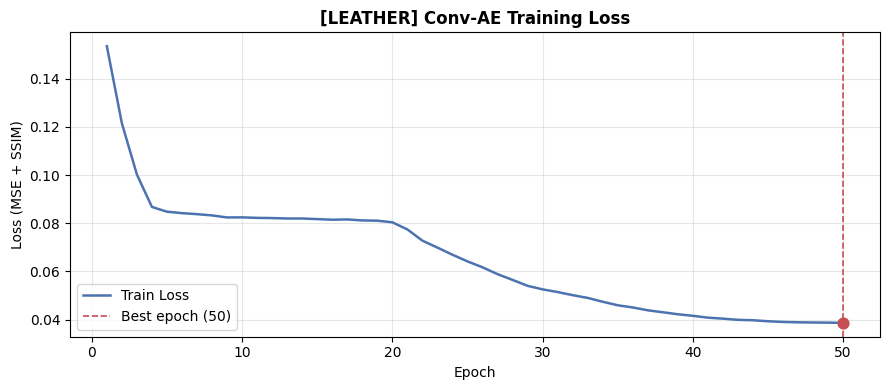

  Loss curve saved: /content/drive/MyDrive/industrial_anomaly_project/results/ae_loss_curve_leather.png

[9] Anomaly scoring...


  AE Scoring [leather]: 100%|██████████| 13/13 [00:04<00:00,  3.10it/s]


  [leather] Scoring done in 4.2s (40.4 ms/img)

[10] Saving results...
  [leather] AE results saved:
     scores (mean) : (104,) | range [0.000651, 0.001957]
     scores (max)  : range [0.025263, 0.420079]
     maps          : (104, 256, 256)
     labels        : normal=22 defective=82

[Cleanup] leather...
  [leather] Memory cleared.

✅ LEATHER done in 8.9 min

════════════════════════════════════════════════════════════
  Processing category: TILE
════════════════════════════════════════════════════════════

[3] Building model...
  Architecture : ConvAE (4-block encoder + 4-block decoder)
  Parameters   : 1.08M
  Bottleneck   : 256 x 16 x 16 = 65,536 dim
   RAM: 2.6/13.6 GB (22%) | VRAM: 0.00/15.64 GB

[2] Building dataloaders...
  [tile] train: 230 | test holdout: 97

[7] Training [tile] for 50 epochs...
  Epoch [  1/50] loss=0.142379  lr=9.99e-04 ← best
  Epoch [  5/50] loss=0.025801  lr=9.76e-04 ← best
  Epoch [ 10/50] loss=0.023354  lr=9.05e-04
  Epoch [ 15/50] loss=0.018297  lr=

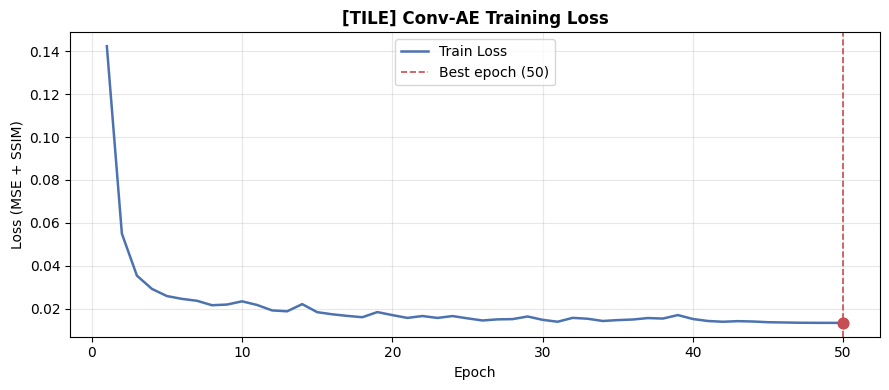

  Loss curve saved: /content/drive/MyDrive/industrial_anomaly_project/results/ae_loss_curve_tile.png

[9] Anomaly scoring...


  AE Scoring [tile]: 100%|██████████| 13/13 [00:03<00:00,  3.94it/s]


  [tile] Scoring done in 3.3s (34.0 ms/img)

[10] Saving results...
  [tile] AE results saved:
     scores (mean) : (97,) | range [0.000766, 0.003059]
     scores (max)  : range [0.052920, 0.223670]
     maps          : (97, 256, 256)
     labels        : normal=23 defective=74

[Cleanup] tile...
  [tile] Memory cleared.

✅ TILE done in 6.8 min

════════════════════════════════════════════════════════════
  Processing category: METAL_NUT
════════════════════════════════════════════════════════════

[3] Building model...
  Architecture : ConvAE (4-block encoder + 4-block decoder)
  Parameters   : 1.08M
  Bottleneck   : 256 x 16 x 16 = 65,536 dim
   RAM: 2.7/13.6 GB (23%) | VRAM: 0.00/15.64 GB

[2] Building dataloaders...
  [metal_nut] train: 220 | test holdout: 100

[7] Training [metal_nut] for 50 epochs...
  Epoch [  1/50] loss=0.234768  lr=9.99e-04 ← best
  Epoch [  5/50] loss=0.078747  lr=9.76e-04 ← best
  Epoch [ 10/50] loss=0.055586  lr=9.05e-04 ← best
  Epoch [ 15/50] loss=0.03983

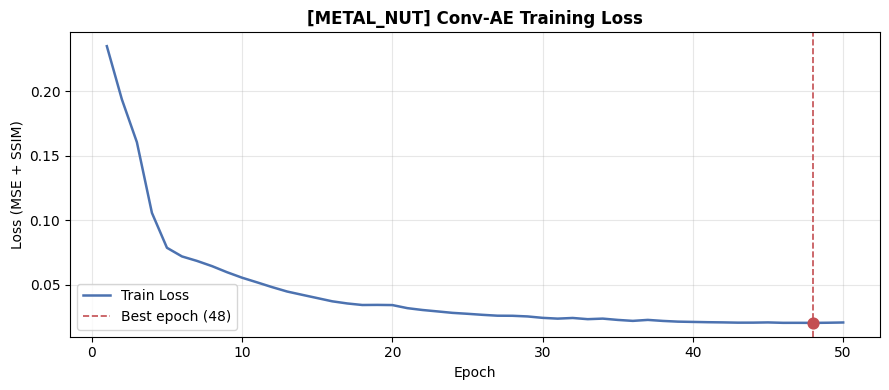

  Loss curve saved: /content/drive/MyDrive/industrial_anomaly_project/results/ae_loss_curve_metal_nut.png

[9] Anomaly scoring...


  AE Scoring [metal_nut]: 100%|██████████| 13/13 [00:02<00:00,  4.90it/s]


  [metal_nut] Scoring done in 2.7s (26.6 ms/img)

[10] Saving results...
  [metal_nut] AE results saved:
     scores (mean) : (100,) | range [0.000439, 0.001111]
     scores (max)  : range [0.044726, 0.116846]
     maps          : (100, 256, 256)
     labels        : normal=17 defective=83

[Cleanup] metal_nut...
  [metal_nut] Memory cleared.

✅ METAL_NUT done in 4.6 min

════════════════════════════════════════════════════════════
  All categories processed.
════════════════════════════════════════════════════════════


In [13]:
# ─────────────────────────────────────────────────────────────────
# STEP 11 — Main pipeline loop
#
# Per category:
#   build model → build loaders → train → plot → score → save → cleanup
#
# Estimated time on T4: ~50-60 min per category
# ─────────────────────────────────────────────────────────────────

ae_metadata = {}

for CATEGORY in CATEGORIES:
    print()
    print('═' * 60)
    print(f'  Processing category: {CATEGORY.upper()}')
    print('═' * 60)
    t_cat = time.time()

    # ── Build model ───────────────────────────────────────────────
    print('\n[3] Building model...')
    model = build_model(DEVICE)
    print_mem()

    # ── Build dataloaders ─────────────────────────────────────────
    print('\n[2] Building dataloaders...')
    train_loader, test_loader = build_dataloaders(CATEGORY)

    # ── Train ─────────────────────────────────────────────────────
    print(f'\n[7] Training [{CATEGORY}] for {AE_EPOCHS} epochs...')
    train_stats = train_model(CATEGORY, model, train_loader, AE_EPOCHS)
    print_mem()

    # ── Plot loss curve ───────────────────────────────────────────
    print('\n[8] Plotting loss curve...')
    plot_loss_curve(
        CATEGORY,
        train_stats['loss_history'],
        train_stats['best_epoch']
    )

    # ── Score test set ────────────────────────────────────────────
    print('\n[9] Anomaly scoring...')
    results = compute_ae_scores(CATEGORY, model, test_loader)

    # ── Save results ──────────────────────────────────────────────
    print('\n[10] Saving results...')
    save_ae_results(CATEGORY, results)

    # ── Collect metadata ──────────────────────────────────────────
    elapsed_cat = time.time() - t_cat
    ae_metadata[CATEGORY] = {
        'n_train_images':    len(train_loader.dataset),
        'n_epochs_trained':  len(train_stats['loss_history']),
        'best_epoch':        train_stats['best_epoch'],
        'best_loss':         round(train_stats['best_loss'], 6),
        'final_loss':        round(train_stats['loss_history'][-1], 6),
        'training_min':      round(train_stats['elapsed_sec'] / 60, 1),
        'n_test_scored':     int(len(results['scores_mean'])),
        'n_test_normal':     int((results['labels'] == 0).sum()),
        'n_test_defective':  int((results['labels'] == 1).sum()),
        'score_min':         float(results['scores_mean'].min()),
        'score_max':         float(results['scores_mean'].max()),
        'elapsed_minutes':   round(elapsed_cat / 60, 1),
    }

    # ── Cleanup ───────────────────────────────────────────────────
    print(f'\n[Cleanup] {CATEGORY}...')
    del model, train_loader, test_loader, results, train_stats
    clear_memory()
    print(f'  [{CATEGORY}] Memory cleared.')

    print(f'\n✅ {CATEGORY.upper()} done in {elapsed_cat/60:.1f} min')

print()
print('═' * 60)
print('  All categories processed.')
print('═' * 60)

---
### STEP 12 — Save Metadata

In [14]:
# ─────────────────────────────────────────────────────────────────
# STEP 12 — Save AE pipeline metadata
# ─────────────────────────────────────────────────────────────────

META_PATH = os.path.join(RESULTS_DRIVE, 'ae_metadata.json')

with open(META_PATH, 'w') as f:
    json.dump(ae_metadata, f, indent=4)

print('✅ AE metadata saved.\n')
print(f'   Path: {META_PATH}\n')

print(f'{"Category":<12} {"Train":<8} {"Best Ep":<10} {"Best Loss":<12} {"Final Loss":<12} {"Time(min)"}')
print('─' * 70)
for cat, m in ae_metadata.items():
    print(
        f"{cat:<12} "
        f"{m['n_train_images']:<8} "
        f"{m['best_epoch']:<10} "
        f"{m['best_loss']:<12.6f} "
        f"{m['final_loss']:<12.6f} "
        f"{m['elapsed_minutes']:.1f}"
    )
print('─' * 70)

✅ AE metadata saved.

   Path: /content/drive/MyDrive/industrial_anomaly_project/results/ae_metadata.json

Category     Train    Best Ep    Best Loss    Final Loss   Time(min)
──────────────────────────────────────────────────────────────────────
leather      245      50         0.038642     0.038642     8.9
tile         230      50         0.013299     0.013299     6.8
metal_nut    220      48         0.020628     0.020937     4.6
──────────────────────────────────────────────────────────────────────


---
### STEP 13 — Final Verification

In [15]:
# ─────────────────────────────────────────────────────────────────
# STEP 13 — Final asset verification
# ─────────────────────────────────────────────────────────────────

print('🔍 Verifying all output files...\n')

expected_files = []
for cat in CATEGORIES:
    expected_files += [
        os.path.join(MODEL_DRIVE,   f'autoencoder_{cat}.pt'),
        os.path.join(RESULTS_DRIVE, f'ae_{cat}_scores.npy'),
        os.path.join(RESULTS_DRIVE, f'ae_{cat}_scores_max.npy'),
        os.path.join(RESULTS_DRIVE, f'ae_{cat}_maps.npy'),
        os.path.join(RESULTS_DRIVE, f'ae_{cat}_labels.npy'),
        os.path.join(RESULTS_DRIVE, f'ae_{cat}_meta.json'),
        os.path.join(RESULTS_DRIVE, f'ae_loss_curve_{cat}.png'),
    ]
expected_files.append(META_PATH)

all_ok = True
for fp in expected_files:
    exists  = os.path.exists(fp)
    size_kb = os.path.getsize(fp) / 1024 if exists else 0
    icon    = '✅' if exists else '❌'
    print(f'  {icon} {os.path.basename(fp):<48} {size_kb:>8.1f} KB')
    if not exists:
        all_ok = False

if not all_ok:
    raise SystemExit('❌ Some output files missing. Check errors above.')

clear_memory()

print()
print('═' * 60)
print('✅ Notebook 03 COMPLETE — Autoencoder Done')
print('═' * 60)
print()
print('📌 Assets saved to Drive:')
print(f'   AE checkpoints → {MODEL_DRIVE}')
print(f'   Scores/maps    → {RESULTS_DRIVE}')
print(f'   Loss curves    → {RESULTS_DRIVE}')
print()
print('📌 Next step: Run 04_evaluation_comparison.ipynb')

🔍 Verifying all output files...

  ✅ autoencoder_leather.pt                            12686.5 KB
  ✅ ae_leather_scores.npy                                 0.5 KB
  ✅ ae_leather_scores_max.npy                             0.5 KB
  ✅ ae_leather_maps.npy                               26624.1 KB
  ✅ ae_leather_labels.npy                                 0.5 KB
  ✅ ae_leather_meta.json                                  7.9 KB
  ✅ ae_loss_curve_leather.png                            40.4 KB
  ✅ autoencoder_tile.pt                               12686.1 KB
  ✅ ae_tile_scores.npy                                    0.5 KB
  ✅ ae_tile_scores_max.npy                                0.5 KB
  ✅ ae_tile_maps.npy                                  24832.1 KB
  ✅ ae_tile_labels.npy                                    0.5 KB
  ✅ ae_tile_meta.json                                     7.5 KB
  ✅ ae_loss_curve_tile.png                               39.6 KB
  ✅ autoencoder_metal_nut.pt                          126